In [ ]:
#all the imports
import re
import string
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

sns.set_style("whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
dataset = load_dataset("ag_news")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

label_names = ["World", "Sports", "Business", "Sci/Tech"]
label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

train_df["label_name"] = train_df["label"].map(label_map)
test_df["label_name"] = test_df["label"].map(label_map)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nSample rows:")
print(train_df.head())

#importing the dataset

NameError: name 'load_dataset' is not defined

In [ ]:
print("\nClass distribution:")
print(train_df["label_name"].value_counts())

print("\nMissing values:")
print(train_df.isnull().sum())

train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))
test_df["text_length"] = test_df["text"].apply(lambda x: len(x.split()))

print("\nText length statistics:")
print(train_df["text_length"].describe())



Class distribution:
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

Missing values:
text          0
label         0
label_name    0
dtype: int64

Text length statistics:
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64


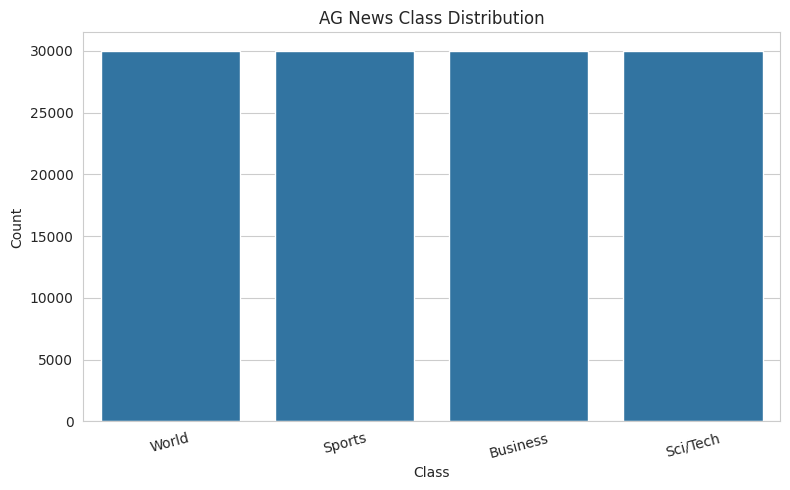

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="label_name", order=label_names)
plt.title("AG News Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

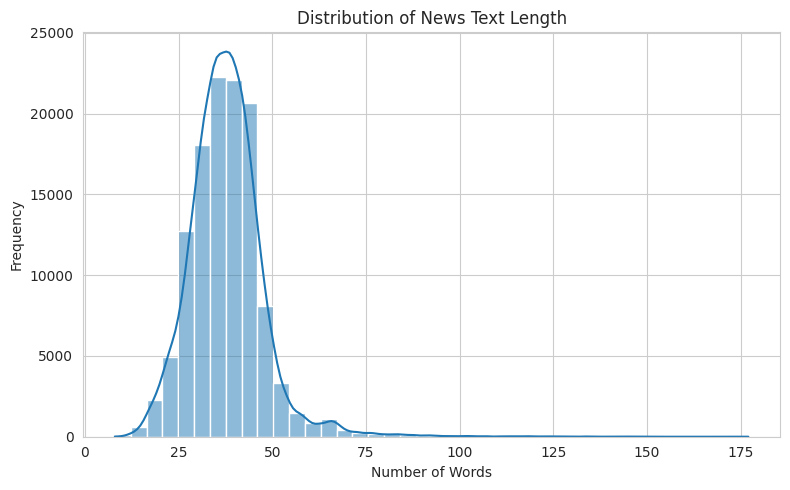

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df["text_length"], bins=40, kde=True)
plt.title("Distribution of News Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

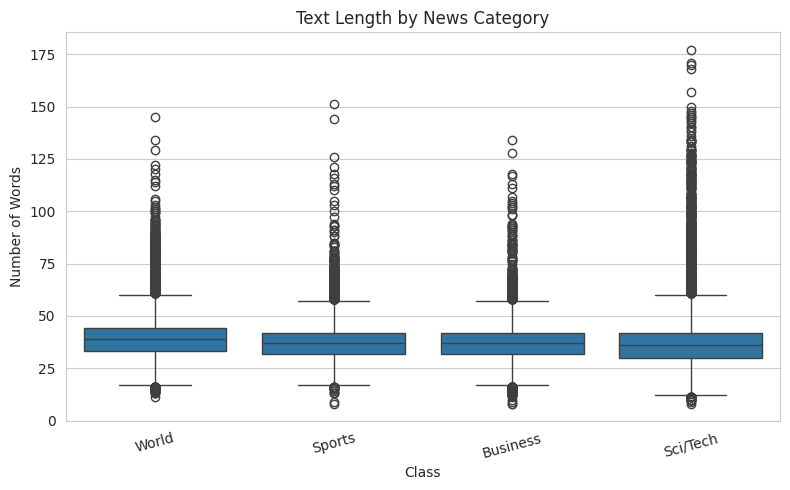

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="label_name", y="text_length", order=label_names)
plt.title("Text Length by News Category")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # this removed URLs
    text = re.sub(r"\d+", "", text)                       #  this removed digits
    text = text.translate(str.maketrans("", "", string.punctuation))  # this removes punctuation
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [ ]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("\nOriginal text example:")
print(train_df.loc[0, "text"])

print("\nCleaned text example:")
print(train_df.loc[0, "clean_text"])

#shows you an example of what the cell above does and shows h


Original text example:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Cleaned text example:
wall st bears claw back black reuters reuters shortsellers wall streets dwindlingband ultracynics seeing green


In [ ]:
bow_vectorizer = CountVectorizer(max_features=10000)

X_train_bow = bow_vectorizer.fit_transform(train_df["clean_text"])
X_test_bow = bow_vectorizer.transform(test_df["clean_text"])

y_train = train_df["label"]
y_test = test_df["label"]

bow_model = LogisticRegression(max_iter=1000)
bow_model.fit(X_train_bow, y_train)

y_pred_bow = bow_model.predict(X_test_bow)

print("\n=== Bag of Words + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow, target_names=label_names))


=== Bag of Words + Logistic Regression ===
Accuracy: 0.8993421052631579
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.95      0.97      0.96      1900
    Business       0.87      0.86      0.87      1900
    Sci/Tech       0.87      0.88      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



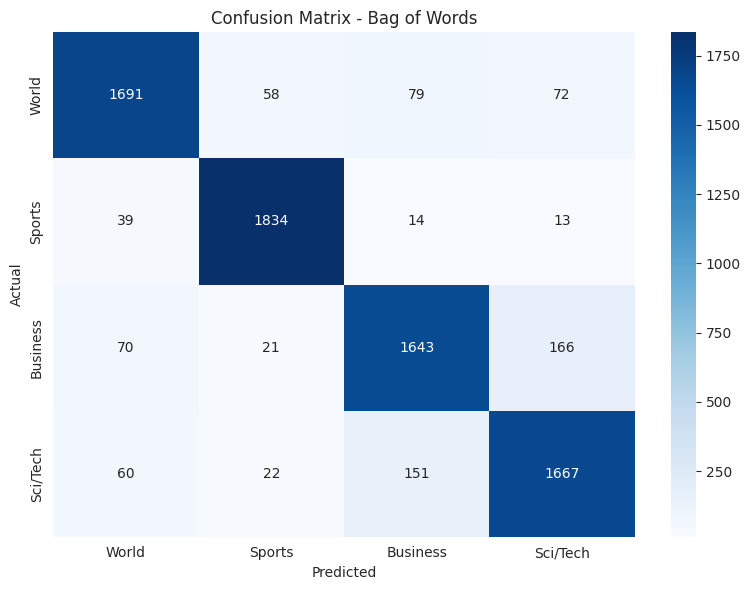

In [ ]:
cm_bow = confusion_matrix(y_test, y_pred_bow)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - Bag of Words")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_text"])

tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

print("\n=== TF-IDF + Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf, target_names=label_names))


=== TF-IDF + Logistic Regression ===
Accuracy: 0.9144736842105263
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.89      0.88      0.88      1900
    Sci/Tech       0.89      0.89      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



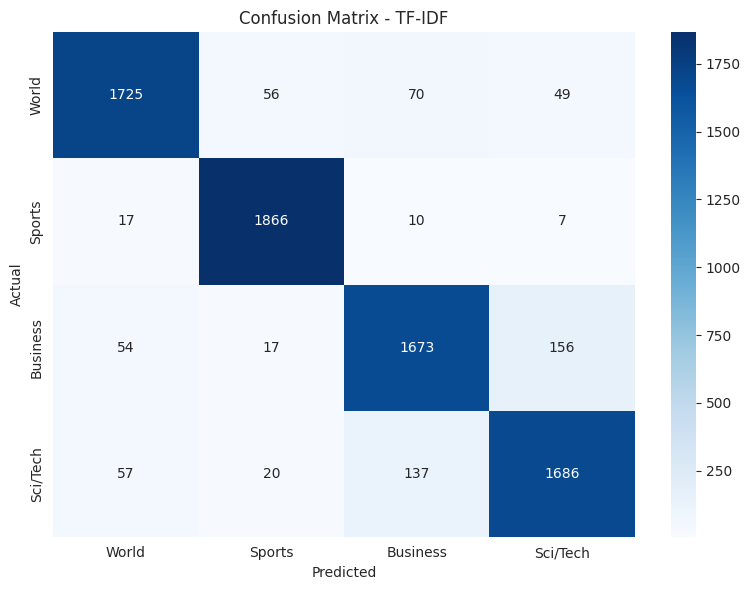

In [ ]:

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - TF-IDF")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Model comparison:
                                Model  Accuracy
0  Bag of Words + Logistic Regression  0.899342
1        TF-IDF + Logistic Regression  0.914474


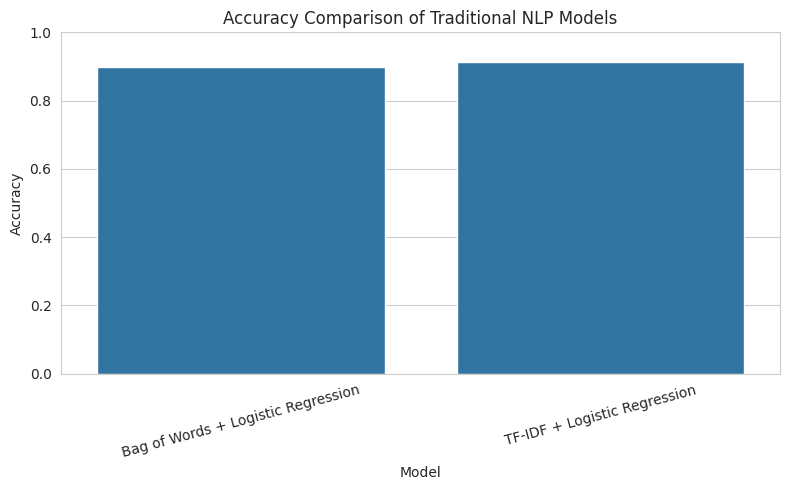

In [ ]:
results_df = pd.DataFrame({
    "Model": ["Bag of Words + Logistic Regression", "TF-IDF + Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_tfidf)
    ]
})

print("\nModel comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Accuracy Comparison of Traditional NLP Models")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

distilbert


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import evaluate

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
train_hf = Dataset.from_pandas(train_df[["text", "label"]])
test_hf = Dataset.from_pandas(test_df[["text", "label"]])

dataset_hf = DatasetDict({
    "train": train_hf,
    "test": test_hf
})

print(dataset_hf)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset_hf.map(tokenize_function, batched=True)

# Keep only the columns Trainer needs
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

print(tokenized_dataset)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_agnews",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.229574,0.173924,0.943553
2,0.136648,0.184373,0.946974


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=15000, training_loss=0.18311119791666666, metrics={'train_runtime': 2748.1696, 'train_samples_per_second': 87.331, 'train_steps_per_second': 5.458, 'total_flos': 7948327403520000.0, 'train_loss': 0.18311119791666666, 'epoch': 2.0})

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
predictions = trainer.predict(tokenized_dataset["test"])
y_pred_distilbert = np.argmax(predictions.predictions, axis=-1)
y_true_distilbert = predictions.label_ids

print("\n=== DistilBERT Classification Report ===")
print("Accuracy:", accuracy_score(y_true_distilbert, y_pred_distilbert))
print(classification_report(y_true_distilbert, y_pred_distilbert, target_names=label_names))


=== DistilBERT Classification Report ===
Accuracy: 0.9435526315789474
              precision    recall  f1-score   support

       World       0.96      0.95      0.95      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.91      0.91      1900
    Sci/Tech       0.91      0.93      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



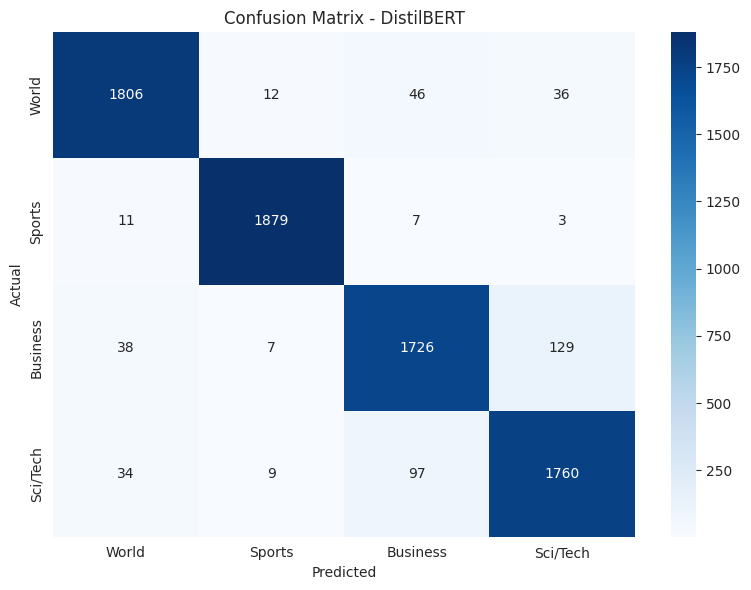

In [ ]:


cm_distilbert = confusion_matrix(y_true_distilbert, y_pred_distilbert)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Updated model comparison:
                                Model  Accuracy
0  Bag of Words + Logistic Regression  0.899342
1        TF-IDF + Logistic Regression  0.914474
2                          DistilBERT  0.943553


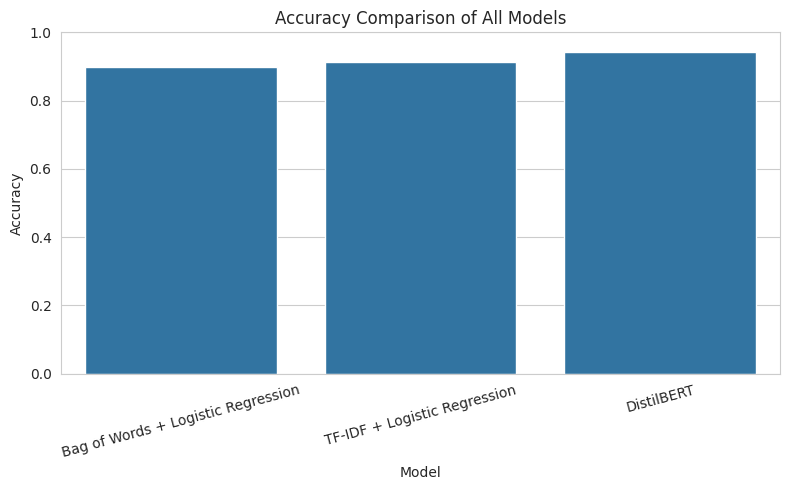

In [ ]:
distilbert_accuracy = accuracy_score(y_true_distilbert, y_pred_distilbert)
bow_accuracy = accuracy_score(y_test, y_pred_bow)
tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)

results_df = pd.DataFrame({
    "Model": [
        "Bag of Words + Logistic Regression",
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        bow_accuracy,
        tfidf_accuracy,
        distilbert_accuracy
    ]
})

print("\nUpdated model comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Accuracy Comparison of All Models")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()